In [ ]:
# ! nvidia-smi

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
import timm

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/kaggle_data/optiver-realized-volatility-prediction'
DIR = '/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/'
LOCAL_DATA_DIR = '/content/data'

!cp -r {DATA_DIR} {LOCAL_DATA_DIR}


class OrderFlowDataset(Dataset):
    def __init__(self, target_csv_path: str, book_path: str, trade_path: str, transform=None):
        self.target = pd.read_csv(target_csv_path)
        self.index_map = self.target[['stock_id', 'time_id']].to_numpy()
        self.target = self.target.to_numpy()

        self.transform = transform

        full_book = pd.read_parquet(book_path)
        full_trade = pd.read_parquet(trade_path)

        self.books = {k: v for k, v in full_book.groupby(['stock_id', 'time_id'])}
        self.trades = {k: v for k, v in full_trade.groupby(['stock_id', 'time_id'])}

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        stock_id, time_id = self.index_map[idx]
        book_data = self.books.get((stock_id, time_id), pd.DataFrame())
        trade_data = self.trades.get((stock_id, time_id), pd.DataFrame())
        target = np.float32(np.log1p(self.target[idx, 2]))

        sample = {'book': book_data, 'trade': trade_data, 'r_vol': target}
        if self.transform:
            sample = self.transform(sample)
        return sample


class ToImage(object):
    def __init__(self, output_size=(600, 600, 4), bounds='auto', pad=True, include_features=True):
        self.output_size = output_size
        self.bounds = bounds
        self.pad = pad
        self.include_features = include_features

    @staticmethod
    def _safe_std(values: np.ndarray) -> float:
        if values.size < 2:
            return 0.0
        return float(np.std(values, ddof=1))

    def _extract_engineered_features(self, book: pd.DataFrame, trade: pd.DataFrame) -> np.ndarray:
        if book.empty:
            return np.zeros(16, dtype=np.float32)

        bid_price1 = book['bid_price1'].to_numpy(dtype=np.float32)
        ask_price1 = book['ask_price1'].to_numpy(dtype=np.float32)
        bid_size1 = book['bid_size1'].to_numpy(dtype=np.float32)
        ask_size1 = book['ask_size1'].to_numpy(dtype=np.float32)
        bid_size2 = book['bid_size2'].to_numpy(dtype=np.float32)
        ask_size2 = book['ask_size2'].to_numpy(dtype=np.float32)
        seconds = book['seconds_in_bucket'].to_numpy(dtype=np.int32)

        denom = bid_size1 + ask_size1 + 1e-8
        wap1 = (bid_price1 * ask_size1 + ask_price1 * bid_size1) / denom
        spread1 = ask_price1 - bid_price1

        wap1_clipped = np.clip(wap1, 1e-8, None)
        if wap1_clipped.size > 1:
            log_ret = np.diff(np.log(wap1_clipped))
            realized_vol = float(np.sqrt(np.sum(log_ret * log_ret)))
        else:
            realized_vol = 0.0

        vol_l1 = bid_size1 + ask_size1
        vol_l2 = bid_size2 + ask_size2
        vol_total = vol_l1 + vol_l2
        vol_imbalance = (bid_size1 - ask_size1) / (bid_size1 + ask_size1 + 1e-8)

        book_update_count = float(len(book))
        unique_seconds_count = float(np.unique(seconds).size)
        mean_spread = float(np.mean(spread1))
        std_spread = self._safe_std(spread1)
        wap1_mean = float(np.mean(wap1))
        vol_sum = float(np.sum(vol_total))
        vol_q90 = float(np.quantile(vol_total, 0.9)) if vol_total.size else 0.0
        vol_imbalance_mean = float(np.mean(vol_imbalance))
        vol_imbalance_std = self._safe_std(vol_imbalance)

        trade_count = 0.0
        trade_size_sum = 0.0
        trade_order_count_sum = 0.0
        trade_avg_size_per_order = 0.0
        trade_inter_arrival_mean = 0.0
        trade_price_return_std = 0.0

        if not trade.empty:
            trade_count = float(len(trade))
            trade_seconds = trade['seconds_in_bucket'].to_numpy(dtype=np.int32)
            trade_size = trade['size'].to_numpy(dtype=np.float32)
            trade_order_count = trade['order_count'].to_numpy(dtype=np.float32)
            trade_price = trade['price'].to_numpy(dtype=np.float32)

            trade_size_sum = float(np.sum(trade_size))
            trade_order_count_sum = float(np.sum(trade_order_count))
            trade_avg_size_per_order = float(np.mean(trade_size / (trade_order_count + 1e-8)))

            if trade_seconds.size > 1:
                trade_inter_arrival_mean = float(np.mean(np.diff(trade_seconds)))

            if trade_price.size > 1:
                trade_price_ret = np.diff(np.log(np.clip(trade_price, 1e-8, None)))
                trade_price_return_std = self._safe_std(trade_price_ret)

        features = np.array([
            book_update_count, unique_seconds_count, mean_spread, std_spread, wap1_mean, realized_vol,
            vol_sum, vol_q90, vol_imbalance_mean, vol_imbalance_std, trade_count, trade_size_sum,
            trade_order_count_sum, trade_avg_size_per_order, trade_inter_arrival_mean, trade_price_return_std,
        ], dtype=np.float32)
        return features

    def __call__(self, sample):
        book, trade, r_vol = sample['book'], sample['trade'], sample['r_vol']
        n_time, n_price, n_channels = self.output_size
        image = np.zeros((n_time, n_price, n_channels), dtype=np.int32)
        features = self._extract_engineered_features(book, trade) if self.include_features else None
        if book.empty:
            output = {'image': image, 'r_vol': r_vol}
            if features is not None:
                output['features'] = features
            return output

        if self.bounds == 'auto':
            mid_price = 0.5 * (
                book['bid_price1'].to_numpy(dtype=np.float32) +
                book['ask_price1'].to_numpy(dtype=np.float32)
            )
            price_reference = float(np.median(mid_price))
            if not np.isfinite(price_reference) or price_reference <= 0:
                price_reference = float(np.median(
                    book[['bid_price1', 'bid_price2', 'ask_price1', 'ask_price2']].to_numpy(dtype=np.float32)
                ))
            if not np.isfinite(price_reference) or price_reference <= 0:
                price_reference = 1.0
            price_edges = np.linspace(-0.02, 0.02, n_price + 1)
        else:
            price_reference = 1.0
            price_edges = np.linspace(float(self.bounds[0]), float(self.bounds[1]), n_price + 1)

        bid_bin_1 = np.searchsorted(price_edges, (book['bid_price1'].to_numpy(dtype=np.float32) - price_reference) / price_reference) - 1
        bid_bin_2 = np.searchsorted(price_edges, (book['bid_price2'].to_numpy(dtype=np.float32) - price_reference) / price_reference) - 1
        ask_bin_1 = np.searchsorted(price_edges, (book['ask_price1'].to_numpy(dtype=np.float32) - price_reference) / price_reference) - 1
        ask_bin_2 = np.searchsorted(price_edges, (book['ask_price2'].to_numpy(dtype=np.float32) - price_reference) / price_reference) - 1

        bid_bin_1 = np.clip(bid_bin_1, 0, n_price - 1)
        bid_bin_2 = np.clip(bid_bin_2, 0, n_price - 1)
        ask_bin_1 = np.clip(ask_bin_1, 0, n_price - 1)
        ask_bin_2 = np.clip(ask_bin_2, 0, n_price - 1)

        sec = book['seconds_in_bucket'].to_numpy(dtype=np.int32)
        bs1 = book['bid_size1'].to_numpy(dtype=np.int32)
        bs2 = book['bid_size2'].to_numpy(dtype=np.int32)
        as1 = book['ask_size1'].to_numpy(dtype=np.int32)
        as2 = book['ask_size2'].to_numpy(dtype=np.int32)

        np.add.at(image, (sec, bid_bin_1, 0), bs1)
        np.add.at(image, (sec, bid_bin_2, 0), bs2)
        np.add.at(image, (sec, ask_bin_1, 1), as1)
        np.add.at(image, (sec, ask_bin_2, 1), as2)

        if not trade.empty:
            trade_sec = trade['seconds_in_bucket'].to_numpy(dtype=np.int32)
            trade_bin = np.searchsorted(price_edges, (trade['price'].to_numpy(dtype=np.float32) - price_reference) / price_reference, side='right') - 1
            trade_bin = np.clip(trade_bin, 0, n_price - 1)
            trade_size = trade['size'].to_numpy(dtype=np.int32)
            trade_oc = trade['order_count'].to_numpy(dtype=np.int32)

            np.add.at(image[:, :, 2], (trade_sec, trade_bin), trade_size)
            if self.pad:
                left_mask = trade_bin - 1 >= 0
                right_mask = trade_bin + 1 < n_price
                np.add.at(image[:, :, 2], (trade_sec[left_mask], trade_bin[left_mask] - 1), trade_size[left_mask])
                np.add.at(image[:, :, 2], (trade_sec[right_mask], trade_bin[right_mask] + 1), trade_size[right_mask])
            np.add.at(image[:, :, 3], (trade_sec, trade_bin), trade_oc)

        output = {'image': image, 'r_vol': r_vol}
        if features is not None:
            output['features'] = features
        return output


class OrderFlowRegressor(nn.Module):
    def __init__(self, tabular_dim):
        super().__init__()
        self.image_encoder = timm.create_model(
            'vit_base_patch16_224',
            pretrained=True,
            in_chans=4,
            num_classes=0,
            global_pool='avg',
            dynamic_img_size=True
        )
        image_dim = self.image_encoder.num_features

        self.feature_encoder = nn.Sequential(
            nn.LayerNorm(tabular_dim),
            nn.Linear(tabular_dim, 128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 128),
            nn.GELU(),
        )

        self.regression_head = nn.Sequential(
            nn.Linear(image_dim + 128, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1),
        )

    def forward(self, image, features):
        H, W = image.shape[2], image.shape[3]
        pad_h = (16 - H % 16) % 16
        pad_w = (16 - W % 16) % 16
        image = F.pad(image, (0, pad_w, 0, pad_h))

        image_embedding = self.image_encoder(image)
        feature_embedding = self.feature_encoder(features)
        fused = torch.cat([image_embedding, feature_embedding], dim=1)
        return F.softplus(self.regression_head(fused).squeeze(-1))


class NormalizedSubset(Dataset):
    def __init__(self, base_dataset, indices, img_mean, img_std, feat_mean, feat_std):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices, dtype=np.int64)
        self.img_mean = img_mean.astype(np.float32)
        self.img_std = img_std.astype(np.float32)
        self.feat_mean = feat_mean.astype(np.float32)
        self.feat_std = feat_std.astype(np.float32)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        sample = self.base_dataset[int(self.indices[i])]
        image = np.log1p(sample['image'].astype(np.float32))
        image = (image - self.img_mean[None, None, :]) / self.img_std[None, None, :]
        image = np.transpose(image, (2, 0, 1)).copy()
        features = sample['features'].astype(np.float32)
        features = (features - self.feat_mean) / self.feat_std
        target = np.float32(sample['r_vol'])
        return {
            'image': torch.from_numpy(image),
            'features': torch.from_numpy(features),
            'r_vol': torch.tensor(target, dtype=torch.float32),
        }

Mounted at /content/drive


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_transform = ToImage(output_size=(600, 80, 4), include_features=True)
base_dataset = OrderFlowDataset(
    f"{LOCAL_DATA_DIR}/train.csv",
    f"{LOCAL_DATA_DIR}/book_train.parquet",
    f"{LOCAL_DATA_DIR}/trade_train.parquet",
    transform=img_transform
)
feature_dim = int(base_dataset[0]["features"].shape[0])
index_df = pd.DataFrame(base_dataset.index_map, columns=["stock_id", "time_id"])

from datetime import datetime
iteration_id = datetime.utcnow().strftime("iter_%Y%m%d_%H%M%S")
RUN_DIR = os.path.join(DIR, "iterations", iteration_id)
os.makedirs(RUN_DIR, exist_ok=True)
DIR = RUN_DIR
print(f"Run artifacts will be saved to: {DIR}")

cpu_count = os.cpu_count() or 0
hyperparameters = {
    "batch_size": 512,
    "num_workers": max(0, cpu_count - 1),
    "pin_memory": True,
    "prefetch_factor": 2
}

cv_config = {
    "n_splits": 5,
    "gap_time_ids": 2,
    "num_epochs": 6,
    "stats_max_samples": 8000,
    "early_stopping_patience": 2,
    "early_stopping_min_delta": 0.0,
    "future_day_blocks_for_rmspe": 3,
}

/tmp/ipykernel_560/3772603788.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.books = {k: v for k, v in full_book.groupby(['stock_id', 'time_id'])}
/tmp/ipykernel_560/3772603788.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.trades = {k: v for k, v in full_trade.groupby(['stock_id', 'time_id'])}


Run artifacts will be saved to: /content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/iterations/iter_20260416_185412


/tmp/ipykernel_560/495662928.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  iteration_id = datetime.utcnow().strftime("iter_%Y%m%d_%H%M%S")


In [3]:
# Active settings: full training.
hyperparameters['batch_size'] = 512
hyperparameters['num_workers'] = max(0, (os.cpu_count() or 0) - 1)
cv_config['n_splits'] = 5
cv_config['gap_time_ids'] = 2
cv_config['num_epochs'] = 6
cv_config['stats_max_samples'] = 8000
cv_config['future_day_blocks_for_rmspe'] = 3

print('Using full training settings:', hyperparameters, cv_config)

Using full training settings: {'batch_size': 512, 'num_workers': 25, 'pin_memory': True, 'prefetch_factor': 2} {'n_splits': 5, 'gap_time_ids': 2, 'num_epochs': 6, 'stats_max_samples': 8000, 'early_stopping_patience': 2, 'early_stopping_min_delta': 0.0, 'future_day_blocks_for_rmspe': 3}


In [9]:
def make_purged_expanding_folds(time_ids, n_splits=5, gap_time_ids=2):
    unique_times = np.array(sorted(np.unique(time_ids)))
    n_times = len(unique_times)
    val_block = max(1, n_times // (n_splits + 1))
    folds = []

    for fold in range(n_splits):
        train_end = val_block * (fold + 1)
        val_start = train_end + gap_time_ids
        val_end = min(val_start + val_block, n_times)

        if val_start >= n_times or val_end <= val_start:
            continue

        train_times = unique_times[:train_end]
        val_times = unique_times[val_start:val_end]

        if len(train_times) == 0 or len(val_times) == 0:
            continue

        folds.append((train_times, val_times))
    return folds


def split_time_ids_into_days(time_ids):
    unique_times = np.array(sorted(np.unique(time_ids)), dtype=np.int64)
    if unique_times.size == 0:
        return []

    split_points = np.where(np.diff(unique_times) > 1)[0]
    days = []
    start = 0
    for split_idx in split_points:
        days.append(unique_times[start:split_idx + 1])
        start = split_idx + 1
    days.append(unique_times[start:])
    return days


def get_future_day_times(train_times, day_blocks, n_future_days=1):
    if len(train_times) == 0 or not day_blocks or n_future_days <= 0:
        return np.array([], dtype=np.int64)

    last_train_time = int(np.max(train_times))
    for i, day_times in enumerate(day_blocks):
        if int(day_times[0]) <= last_train_time <= int(day_times[-1]):
            start = i + 1
            end = min(start + int(n_future_days), len(day_blocks))
            if start >= len(day_blocks):
                return np.array([], dtype=np.int64)
            selected = day_blocks[start:end]
            if not selected:
                return np.array([], dtype=np.int64)
            return np.concatenate(selected)

    return np.array([], dtype=np.int64)


def compute_rmspe(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    y_true = np.clip(np.expm1(y_true), 0.0, None)
    y_pred = np.clip(np.expm1(y_pred), 0.0, None)
    denom = np.clip(np.abs(y_true), eps, None)
    return float(np.sqrt(np.mean(np.square((y_true - y_pred) / denom))))


def compute_global_stats(dataset, sample_indices, max_samples=8000):
    if len(sample_indices) == 0:
        raise ValueError("sample_indices must not be empty")

    rng = np.random.default_rng(42)
    sample_indices = np.asarray(sample_indices, dtype=np.int64)
    if len(sample_indices) > max_samples:
        sample_indices = rng.choice(sample_indices, size=max_samples, replace=False)

    first = dataset[int(sample_indices[0])]
    channels = int(first['image'].shape[-1])
    feat_dim = int(first['features'].shape[0])

    img_sum = np.zeros(channels, dtype=np.float32)
    img_sq_sum = np.zeros(channels, dtype=np.float32)
    img_count = 0

    feat_sum = np.zeros(feat_dim, dtype=np.float32)
    feat_sq_sum = np.zeros(feat_dim, dtype=np.float32)
    feat_count = 0

    for idx in sample_indices:
        sample = dataset[int(idx)]
        image = np.log1p(sample['image'].astype(np.float32))
        image = image.reshape(-1, channels)
        img_sum += image.sum(axis=0)
        img_sq_sum += np.square(image).sum(axis=0)
        img_count += image.shape[0]

        feat = sample['features'].astype(np.float32)
        feat_sum += feat
        feat_sq_sum += np.square(feat)
        feat_count += 1

    img_mean = img_sum / img_count
    img_var = np.maximum((img_sq_sum / img_count) - np.square(img_mean), 1e-6)
    img_std = np.sqrt(img_var)

    feat_mean = feat_sum / feat_count
    feat_var = np.maximum((feat_sq_sum / feat_count) - np.square(feat_mean), 1e-6)
    feat_std = np.sqrt(feat_var)

    return img_mean.astype(np.float32), img_std.astype(np.float32), feat_mean.astype(np.float32), feat_std.astype(np.float32)


def evaluate_fold_rmspe(model_path, eval_indices):
    if len(eval_indices) == 0:
        return np.nan

    ckpt = torch.load(model_path, map_location=device, weights_only=False)
    eval_ds = NormalizedSubset(
        base_dataset,
        eval_indices,
        ckpt['img_mean'],
        ckpt['img_std'],
        ckpt['feat_mean'],
        ckpt['feat_std'],
    )

    eval_loader = DataLoader(eval_ds, shuffle=False, **hyperparameters)
    model = OrderFlowRegressor(tabular_dim=int(ckpt['feature_dim'])).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    preds_all = []
    targets_all = []

    with torch.no_grad():
        for batch in eval_loader:
            images = batch['image'].to(device, dtype=torch.float32, non_blocking=True)
            features = batch['features'].to(device, dtype=torch.float32, non_blocking=True)
            targets = batch['r_vol'].to(device, dtype=torch.float32, non_blocking=True)

            if device.type == 'cuda':
                with autocast('cuda', dtype=torch.bfloat16):
                    preds = model(images, features)
            else:
                preds = model(images, features)

            preds_all.append(preds.detach().float().cpu().numpy())
            targets_all.append(targets.detach().float().cpu().numpy())

    preds_all = np.concatenate(preds_all, axis=0)
    targets_all = np.concatenate(targets_all, axis=0)
    return compute_rmspe(targets_all, preds_all)


def train_one_fold(fold_id, train_indices, val_indices):
    img_mean, img_std, feat_mean, feat_std = compute_global_stats(
        base_dataset,
        train_indices,
        max_samples=cv_config['stats_max_samples']
    )

    train_ds = NormalizedSubset(base_dataset, train_indices, img_mean, img_std, feat_mean, feat_std)
    val_ds = NormalizedSubset(base_dataset, val_indices, img_mean, img_std, feat_mean, feat_std)

    train_loader = DataLoader(train_ds, shuffle=True, **hyperparameters)
    val_loader = DataLoader(val_ds, shuffle=False, **hyperparameters)

    model = OrderFlowRegressor(tabular_dim=feature_dim).to(device)
    criterion = nn.HuberLoss()

    optimizer_adamw = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    num_epochs = cv_config['num_epochs']
    total_steps = len(train_loader) * num_epochs
    warmup_steps = max(1, int(0.1 * total_steps))
    decay_steps = max(1, total_steps - warmup_steps)

    warmup = LinearLR(optimizer_adamw, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps)
    cosine = CosineAnnealingLR(optimizer_adamw, T_max=decay_steps, eta_min=1e-6)
    scheduler = SequentialLR(optimizer_adamw, schedulers=[warmup, cosine], milestones=[warmup_steps])
    scaler = GradScaler('cuda')

    best_val = float('inf')
    best_epoch = -1
    bad_epochs = 0
    patience = int(cv_config.get('early_stopping_patience', 2))
    min_delta = float(cv_config.get('early_stopping_min_delta', 0.0))
    best_model_path = f"{DIR}/best_model_fold_{fold_id}.pth"
    fold_history = []

    for epoch in range(num_epochs):
        model.train()
        train_loss_sum = 0.0

        for batch in train_loader:
            images = batch['image'].to(device, dtype=torch.float32, non_blocking=True)
            features = batch['features'].to(device, dtype=torch.float32, non_blocking=True)
            targets = batch['r_vol'].to(device, dtype=torch.float32, non_blocking=True)

            optimizer_adamw.zero_grad()

            with autocast('cuda', dtype=torch.bfloat16):
                preds = model(images, features)
                loss = criterion(preds, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer_adamw)
            scaler.update()
            scheduler.step()

            train_loss_sum += loss.item() * images.size(0)

        train_loss = train_loss_sum / len(train_ds)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(device, dtype=torch.float32, non_blocking=True)
                features = batch['features'].to(device, dtype=torch.float32, non_blocking=True)
                targets = batch['r_vol'].to(device, dtype=torch.float32, non_blocking=True)

                with autocast('cuda', dtype=torch.bfloat16):
                    preds = model(images, features)
                    loss = criterion(preds, targets)

                val_loss_sum += loss.item() * images.size(0)

        val_loss = val_loss_sum / len(val_ds)
        fold_history.append({
            'fold': fold_id,
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
        })

        improved = val_loss < (best_val - min_delta)
        if improved:
            best_val = val_loss
            best_epoch = epoch + 1
            bad_epochs = 0
            torch.save({
                'fold': fold_id,
                'epoch': best_epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer_adamw.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'scaler_state_dict': scaler.state_dict(),
                'best_val_loss': best_val,
                'img_mean': img_mean,
                'img_std': img_std,
                'feat_mean': feat_mean,
                'feat_std': feat_std,
                'feature_dim': feature_dim,
            }, best_model_path)
        else:
            bad_epochs += 1

        print(f"Fold {fold_id} | Epoch {epoch+1}/{num_epochs} | Train {train_loss:.6f} | Val {val_loss:.6f} | Best {best_val:.6f}")

        if bad_epochs >= patience:
            print(f"Fold {fold_id} early stopping triggered at epoch {epoch+1} (best epoch {best_epoch}).")
            break

    return best_val, fold_history, best_model_path

In [13]:
# Override future-day selection so it starts immediately after validation end.
def get_future_day_times(anchor_times, day_blocks, n_future_days=1):
    if len(anchor_times) == 0 or not day_blocks or n_future_days <= 0:
        return np.array([], dtype=np.int64)

    anchor_time = int(np.max(anchor_times))
    anchor_day_idx = None
    for i, day_times in enumerate(day_blocks):
        if int(day_times[0]) <= anchor_time <= int(day_times[-1]):
            anchor_day_idx = i
            break

    if anchor_day_idx is None:
        return np.array([], dtype=np.int64)

    selected_blocks = []
    blocks_used = 0

    # Use the remaining portion of the anchor day block first, if available,
    # so the future window connects directly after validation.
    anchor_remainder = day_blocks[anchor_day_idx][day_blocks[anchor_day_idx] > anchor_time]
    if anchor_remainder.size > 0:
        selected_blocks.append(anchor_remainder)
        blocks_used += 1

    next_idx = anchor_day_idx + 1
    while blocks_used < int(n_future_days) and next_idx < len(day_blocks):
        selected_blocks.append(day_blocks[next_idx])
        blocks_used += 1
        next_idx += 1

    if not selected_blocks:
        return np.array([], dtype=np.int64)

    return np.concatenate(selected_blocks).astype(np.int64)

## Time-aware Cross-Validation Visualization
This chart shows each fold's train, purged gap, validation, and future-day evaluation windows across the ordered `time_id` timeline.

In [10]:
# Visualize time-aware CV layout (train/gap/validation/future-day) on a timeline.
import numpy as np
import matplotlib.pyplot as plt

def _contiguous_runs(sorted_positions: np.ndarray):
    if sorted_positions.size == 0:
        return []
    runs = []
    start = int(sorted_positions[0])
    prev = int(sorted_positions[0])
    for pos in sorted_positions[1:]:
        pos = int(pos)
        if pos == prev + 1:
            prev = pos
            continue
        runs.append((start, prev))
        start = pos
        prev = pos
    runs.append((start, prev))
    return runs

def _draw_time_blocks(ax, y_center, positions, color, label=None, height=0.7, alpha=0.9):
    positions = np.asarray(sorted(set(int(x) for x in positions)), dtype=np.int64)
    for i, (start, end) in enumerate(_contiguous_runs(positions)):
        ax.broken_barh(
            [(start - 0.5, (end - start + 1))],
            (y_center - height / 2.0, height),
            facecolors=color,
            edgecolors='none',
            alpha=alpha,
            label=label if i == 0 else None,
        )

def visualize_time_aware_cv(time_ids, n_splits=5, gap_time_ids=2, n_future_days=1):
    unique_times = np.array(sorted(np.unique(time_ids)), dtype=np.int64)
    if unique_times.size == 0:
        raise ValueError('time_ids is empty.')

    folds = make_purged_expanding_folds(
        unique_times,
        n_splits=n_splits,
        gap_time_ids=gap_time_ids,
    )
    day_blocks = split_time_ids_into_days(unique_times)

    if not folds:
        raise ValueError('No valid folds generated. Check n_splits/gap_time_ids.')

    time_to_pos = {int(t): i for i, t in enumerate(unique_times)}

    fig_h = max(4.0, 1.0 + 1.0 * len(folds))
    fig, ax = plt.subplots(figsize=(16, fig_h))

    first_labels = {
        'train': 'Train window',
        'gap': 'Purged gap',
        'val': 'Validation window',
        'future': f'Future-day window (next {n_future_days} day block(s))',
    }

    for fold_idx, (train_times, val_times) in enumerate(folds):
        y = len(folds) - 1 - fold_idx

        train_pos = [time_to_pos[int(t)] for t in train_times if int(t) in time_to_pos]
        val_pos = [time_to_pos[int(t)] for t in val_times if int(t) in time_to_pos]

        max_train = int(np.max(train_times))
        min_val = int(np.min(val_times))
        gap_times = unique_times[(unique_times > max_train) & (unique_times < min_val)]
        gap_pos = [time_to_pos[int(t)] for t in gap_times]

        future_times = get_future_day_times(val_times, day_blocks, n_future_days=n_future_days)
        future_pos = [time_to_pos[int(t)] for t in future_times if int(t) in time_to_pos]

        _draw_time_blocks(ax, y, train_pos, color='#4e79a7', label=first_labels['train'])
        _draw_time_blocks(ax, y, gap_pos, color='#f28e2b', label=first_labels['gap'])
        _draw_time_blocks(ax, y, val_pos, color='#e15759', label=first_labels['val'])
        _draw_time_blocks(ax, y, future_pos, color='#59a14f', label=first_labels['future'], alpha=0.35)

        first_labels = {k: None for k in first_labels}

    ax.set_yticks(np.arange(len(folds)))
    ax.set_yticklabels([f'Fold {i + 1}' for i in range(len(folds) - 1, -1, -1)])
    ax.set_xlabel('Sorted unique time_id index')
    ax.set_ylabel('Cross-validation fold')
    ax.set_title('Time-aware Purged Expanding CV Timeline')
    ax.set_xlim(-0.5, len(unique_times) - 0.5)
    ax.grid(axis='x', linestyle='--', alpha=0.25)
    ax.legend(loc='upper right', frameon=True)
    plt.tight_layout()
    plt.show()

visualize_time_aware_cv(
    index_df['time_id'].to_numpy(),
    n_splits=cv_config['n_splits'],
    gap_time_ids=cv_config['gap_time_ids'],
    n_future_days=int(cv_config.get('future_day_blocks_for_rmspe', 1)),
)

NameError: name 'index_df' is not defined

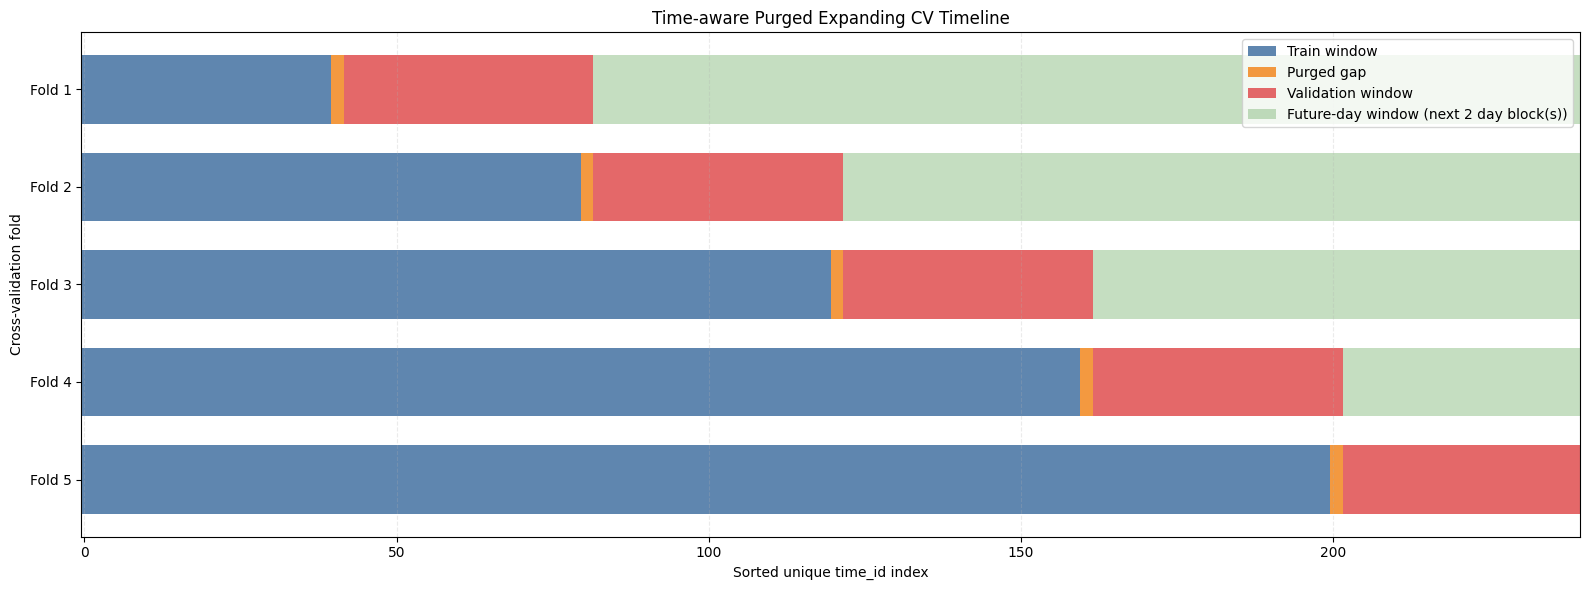

Smoke test passed: visualization rendered with synthetic time_ids.


In [14]:
# Smoke test: synthetic timeline for visualization (no dataset/index_df required).
synthetic_time_ids = np.concatenate([
    np.arange(0, 80),
    np.arange(100, 180),
    np.arange(220, 300),
]).astype(np.int64)

visualize_time_aware_cv(
    synthetic_time_ids,
    n_splits=5,
    gap_time_ids=2,
    n_future_days=2,
)

print('Smoke test passed: visualization rendered with synthetic time_ids.')

In [ ]:
def main():
    """Full training loop with fold validation and multi-day future RMSPE evaluation."""
    print("="*80)
    print("Starting full training with cross-validation")
    print(f"Configuration: {cv_config}")
    print(f"Hyperparameters: {hyperparameters}")
    print("="*80)

    time_ids = index_df['time_id'].to_numpy()
    folds = make_purged_expanding_folds(
        time_ids,
        n_splits=cv_config['n_splits'],
        gap_time_ids=cv_config['gap_time_ids']
    )
    day_blocks = split_time_ids_into_days(time_ids)
    n_future_days = int(cv_config.get('future_day_blocks_for_rmspe', 1))

    print(f"Created {len(folds)} folds for cross-validation")
    print(f"Detected {len(day_blocks)} contiguous time-id day blocks")
    print(f"Future-day RMSPE uses next {n_future_days} day block(s)")

    all_results = []

    for fold_idx, (train_times, val_times) in enumerate(folds):
        print(f"\n{'='*80}")
        print(f"Training fold {fold_idx + 1}/{len(folds)}")
        print(f"{'='*80}")

        train_mask = np.isin(time_ids, train_times)
        val_mask = np.isin(time_ids, val_times)

        train_indices = np.where(train_mask)[0]
        val_indices = np.where(val_mask)[0]

        print(f"Fold {fold_idx}: {len(train_indices)} training samples, {len(val_indices)} validation samples")

        best_val, fold_history, best_model_path = train_one_fold(fold_idx, train_indices, val_indices)

        future_times = get_future_day_times(val_times, day_blocks, n_future_days=n_future_days)
        future_indices = np.where(np.isin(time_ids, future_times))[0]

        if len(future_indices) > 0:
            future_day_rmspe = evaluate_fold_rmspe(best_model_path, future_indices)
            print(
                f"Fold {fold_idx}: future-day RMSPE={future_day_rmspe:.6f} "
                f"on {len(future_indices)} samples ({len(future_times)} time_ids)."
            )
        else:
            future_day_rmspe = np.nan
            print(f"Fold {fold_idx}: no future day blocks available, skipping future-day RMSPE.")

        all_results.append({
            'fold': fold_idx,
            'best_val_loss': best_val,
            'num_train_samples': len(train_indices),
            'num_val_samples': len(val_indices),
            'num_future_day_samples': len(future_indices),
            'future_day_blocks_used': n_future_days,
            'future_day_rmspe': future_day_rmspe,
        })

    cv_df = pd.DataFrame(all_results)
    scores_path = f"{DIR}/cv_scores.csv"
    future_scores_path = f"{DIR}/cv_future_day_rmspe.csv"

    cv_df.to_csv(scores_path, index=False)
    cv_df[['fold', 'future_day_rmspe', 'num_future_day_samples', 'future_day_blocks_used']].to_csv(future_scores_path, index=False)

    print(f"\n{'='*80}")
    print(f"Cross-validation complete. Results saved to {scores_path}")
    print(f"Future-day RMSPE saved to {future_scores_path}")
    print(cv_df.to_string(index=False))
    print("="*80)

In [6]:
if __name__ == "__main__":
    main()

Starting full training with cross-validation
Configuration: {'n_splits': 5, 'gap_time_ids': 2, 'num_epochs': 6, 'stats_max_samples': 8000, 'early_stopping_patience': 2, 'early_stopping_min_delta': 0.0, 'future_day_blocks_for_rmspe': 3}
Hyperparameters: {'batch_size': 512, 'num_workers': 25, 'pin_memory': True, 'prefetch_factor': 2}
Created 5 folds for cross-validation
Detected 3402 contiguous time-id day blocks
Future-day RMSPE uses next 3 day block(s)

Training fold 1/5
Fold 0: 71454 training samples, 71446 validation samples


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Fold 0 | Epoch 1/6 | Train 0.009208 | Val 0.000005 | Best 0.000005
Fold 0 | Epoch 2/6 | Train 0.000005 | Val 0.000003 | Best 0.000003
Fold 0 | Epoch 3/6 | Train 0.000004 | Val 0.000003 | Best 0.000003
Fold 0 | Epoch 4/6 | Train 0.000003 | Val 0.000002 | Best 0.000002
Fold 0 | Epoch 5/6 | Train 0.000003 | Val 0.000002 | Best 0.000002
Fold 0 | Epoch 6/6 | Train 0.000003 | Val 0.000002 | Best 0.000002


Fold 0: future-day RMSPE=0.808405 on 336 samples (3 time_ids).

Training fold 2/5
Fold 1: 142900 training samples, 71453 validation samples


...

Fold 2: future-day RMSPE=0.758493 on 448 samples (4 time_ids).

Training fold 4/5
Fold 3: 285805 training samples, 71451 validation samples


Fold 3 | Epoch 1/6 | Train 0.003777 | Val 0.000002 | Best 0.000002
Fold 3 | Epoch 2/6 | Train 0.000002 | Val 0.000001 | Best 0.000001
Fold 3 | Epoch 3/6 | Train 0.000002 | Val 0.000001 | Best 0.000001
Fold 3 | Epoch 4/6 | Train 0.000002 | Val 0.000001 | Best 0.000001
Fold 3 | Epoch 5/6 | Train 0.000002 | Val 0.000001 | Best 0.000001
Fold 3 | Epoch 6/6 | Train 0.000002 | Val 0.000001 | Best 0.000001


Fold 3: future-day RMSPE=0.303890 on 336 samples (3 time_ids).

Training fold 5/5
Fold 4: 357256 training samples, 71452 validation samples


Fold 4 | Epoch 1/6 | Train 0.002767 | Val 0.000002 | Best 0.000002
Fold 4 | Epoch 2/6 | Train 0.000003 | Val 0.000001 | Best 0.000001
Fold 4 | Epoch 3/6 | Train 0.000002 | Val 0.000001 | Best 0.000001
Fold 4 | Epoch 4/6 | Train 0.000002 | Val 0.000001 | Best 0.000001
Fold 4 | Epoch 5/6 | Train 0.000002 | Val 0.000001 | Best 0.000001
Fold 4 | Epoch 6/6 | Train 0.000002 | Val 0.000001 | Best 0.000001


Fold 4: future-day RMSPE=0.446887 on 336 samples (3 time_ids).

Cross-validation complete. Results saved to /content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/iterations/iter_20260416_185412/cv_scores.csv
Future-day RMSPE saved to /content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/iterations/iter_20260416_185412/cv_future_day_rmspe.csv
 fold  best_val_loss  num_train_samples  num_val_samples  num_future_day_samples  future_day_blocks_used  future_day_rmspe
    0   2.311236e-06              71454            71446                     336                       3          0.808405
    1   1.853366e-06             142900            71453                     336                       3          0.798046
    2   1.556458e-06             214353            71452                     448                       3          0.758493
    3   1.016619e-06             285805            71451                     336                       3          0.303890
    4   9.288213e-07             357256    

In [ ]:
# Smoke-test settings reference (kept separate on purpose).
SMOKE_HYPERPARAMETERS = {
    'batch_size': 64,
    'num_workers': 2,
}

SMOKE_CV_CONFIG = {
    'n_splits': 1,
    'gap_time_ids': 1,
    'num_epochs': 1,
    'stats_max_samples': 512,
}

def apply_smoke_settings(hparams, cfg):
    hparams.update(SMOKE_HYPERPARAMETERS)
    cfg.update(SMOKE_CV_CONFIG)
    print('Applied smoke settings:', hparams, cfg)

# To use later, run: apply_smoke_settings(hyperparameters, cv_config)

In [7]:
# Fold stability diagnostic prioritizing future-day RMSPE when available.
import os
import numpy as np
import pandas as pd

scores_path = f"{DIR}/cv_scores.csv"
future_scores_path = f"{DIR}/cv_future_day_rmspe.csv"

if os.path.exists(future_scores_path):
    df_scores = pd.read_csv(future_scores_path)
elif 'future_eval_df' in globals() and isinstance(future_eval_df, pd.DataFrame) and not future_eval_df.empty:
    df_scores = future_eval_df.copy()
elif 'cv_df' in globals() and isinstance(cv_df, pd.DataFrame) and not cv_df.empty:
    df_scores = cv_df.copy()
elif os.path.exists(scores_path):
    df_scores = pd.read_csv(scores_path)
else:
    raise FileNotFoundError(
        f"No fold scores found. Run training/evaluation first or ensure {scores_path} exists."
    )

if 'future_day_rmspe' in df_scores.columns and df_scores['future_day_rmspe'].notna().any():
    metric_col = 'future_day_rmspe'
    metric_label = 'future_day_rmspe'
else:
    if 'best_val_loss' not in df_scores.columns:
        raise ValueError("Expected 'future_day_rmspe' or 'best_val_loss' in fold score data.")
    metric_col = 'best_val_loss'
    metric_label = 'best_val_loss'

metric_values = df_scores[metric_col].astype(float).to_numpy()
metric_values = metric_values[~np.isnan(metric_values)]

if metric_values.size == 0:
    raise ValueError(f"No valid values found for metric {metric_col}.")

mean_metric = float(np.mean(metric_values))
std_metric = float(np.std(metric_values, ddof=1)) if metric_values.size > 1 else 0.0
cv_ratio = float(std_metric / (mean_metric + 1e-12))
spread_ratio = float((np.max(metric_values) - np.min(metric_values)) / (mean_metric + 1e-12))

print('Fold Stability Diagnostic')
print(f"metric={metric_label}")
print(f"n_folds={len(metric_values)}")
print(f"mean_{metric_label}={mean_metric:.8f}")
print(f"std_{metric_label}={std_metric:.8f}")
print(f"cv_ratio={cv_ratio:.4f}")
print(f"min_max_spread_ratio={spread_ratio:.4f}")

# RMSPE-specific thresholds are looser than loss thresholds because fold-to-fold
# ratio variability is naturally higher on relative-error metrics.
if metric_label == 'future_day_rmspe':
    stable_cv_thr = 0.18
    stable_spread_thr = 0.50
    moderate_cv_thr = 0.35
    moderate_spread_thr = 0.90
else:
    stable_cv_thr = 0.10
    stable_spread_thr = 0.25
    moderate_cv_thr = 0.20
    moderate_spread_thr = 0.40

print(
    f"thresholds(stable<=cv {stable_cv_thr:.2f}, spread {stable_spread_thr:.2f}; "
    f"moderate<=cv {moderate_cv_thr:.2f}, spread {moderate_spread_thr:.2f})"
)

if metric_values.size < 5:
    recommendation = 'Increase to at least 5-6 folds for a more reliable estimate.'
elif cv_ratio <= stable_cv_thr and spread_ratio <= stable_spread_thr:
    recommendation = 'Current folds look stable. Keeping 5-6 folds is reasonable.'
elif cv_ratio <= moderate_cv_thr and spread_ratio <= moderate_spread_thr:
    recommendation = 'Moderate variability. Consider 8 folds if compute budget allows.'
else:
    recommendation = 'High variability. Consider 8-10 folds or revisiting split design/features.'

print(f"Recommendation: {recommendation}")

Fold Stability Diagnostic
metric=future_day_rmspe
n_folds=5
mean_future_day_rmspe=0.62314454
std_future_day_rmspe=0.23249793
cv_ratio=0.3731
min_max_spread_ratio=0.8096
thresholds(stable<=cv 0.18, spread 0.50; moderate<=cv 0.35, spread 0.90)
Recommendation: High variability. Consider 8-10 folds or revisiting split design/features.


In [ ]:
# Evaluate future-day RMSPE for existing saved fold checkpoints (no retraining required).
time_ids = index_df['time_id'].to_numpy()
folds = make_purged_expanding_folds(
    time_ids,
    n_splits=cv_config['n_splits'],
    gap_time_ids=cv_config['gap_time_ids']
)
day_blocks = split_time_ids_into_days(time_ids)
n_future_days = int(cv_config.get('future_day_blocks_for_rmspe', 1))

future_eval_rows = []
for fold_idx, (train_times, val_times) in enumerate(folds):
    model_path = f"{DIR}/best_model_fold_{fold_idx}.pth"
    if not os.path.exists(model_path):
        print(f"Fold {fold_idx}: checkpoint missing at {model_path}; skipping")
        continue

    future_times = get_future_day_times(val_times, day_blocks, n_future_days=n_future_days)
    future_indices = np.where(np.isin(time_ids, future_times))[0]

    if len(future_indices) == 0:
        fold_rmspe = np.nan
        print(f"Fold {fold_idx}: no future day blocks available")
    else:
        fold_rmspe = evaluate_fold_rmspe(model_path, future_indices)
        print(
            f"Fold {fold_idx}: future-day RMSPE={fold_rmspe:.6f} "
            f"on {len(future_indices)} samples ({len(future_times)} time_ids, next {n_future_days} day block(s))"
        )

    future_eval_rows.append({
        'fold': fold_idx,
        'num_future_day_samples': len(future_indices),
        'future_day_blocks_used': n_future_days,
        'future_day_rmspe': fold_rmspe,
    })

future_eval_df = pd.DataFrame(future_eval_rows)
future_eval_path = f"{DIR}/cv_future_day_rmspe.csv"
future_eval_df.to_csv(future_eval_path, index=False)
print(f"Saved future-day RMSPE to: {future_eval_path}")
future_eval_df

Fold 0: future-day RMSPE=0.808405 on 336 samples (3 time_ids, next 3 day block(s))


Fold 1: future-day RMSPE=0.798046 on 336 samples (3 time_ids, next 3 day block(s))


Fold 2: future-day RMSPE=0.758493 on 448 samples (4 time_ids, next 3 day block(s))


Fold 3: future-day RMSPE=0.303890 on 336 samples (3 time_ids, next 3 day block(s))


Fold 4: future-day RMSPE=0.446887 on 336 samples (3 time_ids, next 3 day block(s))
Saved future-day RMSPE to: /content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/iterations/iter_20260416_185412/cv_future_day_rmspe.csv


,fold,num_future_day_samples,future_day_blocks_used,future_day_rmspe
0,0,336,3,0.808405
1,1,336,3,0.798046
2,2,448,3,0.758493
3,3,336,3,0.303890
4,4,336,3,0.446887


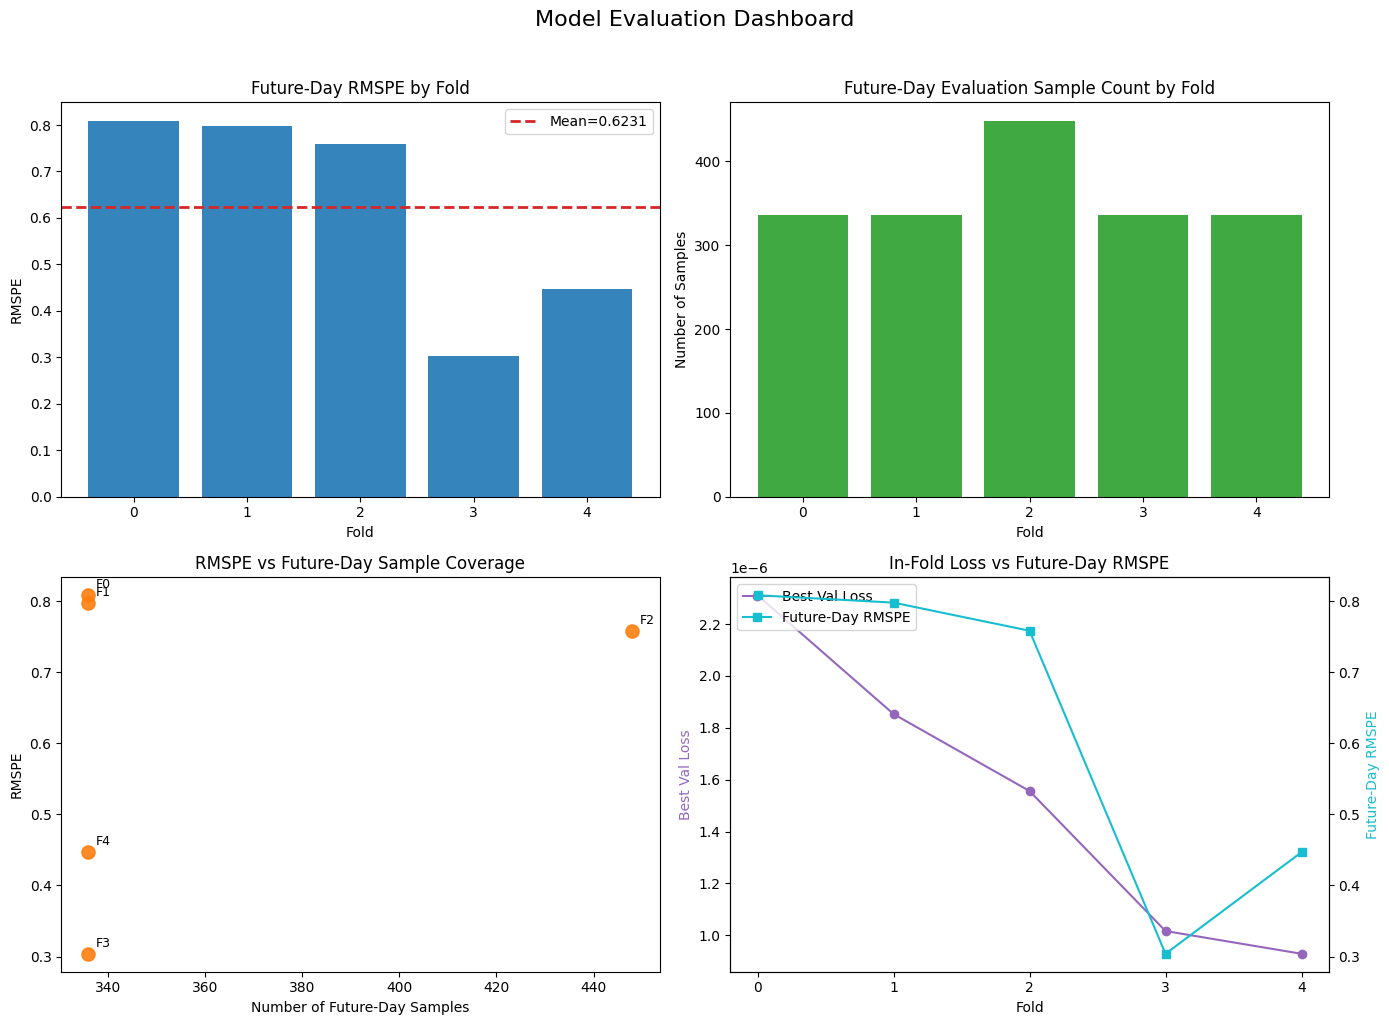

Summary stats:
 fold  future_day_rmspe  num_future_day_samples
    0          0.808405                     336
    1          0.798046                     336
    2          0.758493                     448
    3          0.303890                     336
    4          0.446887                     336
Mean future-day RMSPE: 0.623145


In [9]:
# Visualization dashboard for fold-level model evaluation.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scores_path = f"{DIR}/cv_scores.csv"
future_scores_path = f"{DIR}/cv_future_day_rmspe.csv"

if os.path.exists(future_scores_path):
    viz_df = pd.read_csv(future_scores_path)
elif 'future_eval_df' in globals() and isinstance(future_eval_df, pd.DataFrame) and not future_eval_df.empty:
    viz_df = future_eval_df.copy()
else:
    raise FileNotFoundError(
        f"Future RMSPE file not found at {future_scores_path}. Run future-day evaluation first."
    )

if os.path.exists(scores_path):
    cv_base = pd.read_csv(scores_path)
    merge_cols = [c for c in ['fold', 'best_val_loss', 'num_train_samples', 'num_val_samples'] if c in cv_base.columns]
    viz_df = viz_df.merge(cv_base[merge_cols], on='fold', how='left')

viz_df = viz_df.sort_values('fold').reset_index(drop=True)

required_cols = ['fold', 'future_day_rmspe', 'num_future_day_samples']
missing_cols = [c for c in required_cols if c not in viz_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for visualization: {missing_cols}")

folds = viz_df['fold'].astype(int).to_numpy()
rmspe = viz_df['future_day_rmspe'].astype(float).to_numpy()
samples = viz_df['num_future_day_samples'].astype(float).to_numpy()
mean_rmspe = float(np.nanmean(rmspe))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) RMSPE by fold
axes[0, 0].bar(folds, rmspe, color='#1f77b4', alpha=0.9)
axes[0, 0].axhline(mean_rmspe, color='#d62728', linestyle='--', linewidth=2, label=f'Mean={mean_rmspe:.4f}')
axes[0, 0].set_title('Future-Day RMSPE by Fold')
axes[0, 0].set_xlabel('Fold')
axes[0, 0].set_ylabel('RMSPE')
axes[0, 0].set_xticks(folds)
axes[0, 0].legend()

# (2) Future-day sample count by fold
axes[0, 1].bar(folds, samples, color='#2ca02c', alpha=0.9)
axes[0, 1].set_title('Future-Day Evaluation Sample Count by Fold')
axes[0, 1].set_xlabel('Fold')
axes[0, 1].set_ylabel('Number of Samples')
axes[0, 1].set_xticks(folds)

# (3) RMSPE vs sample count scatter
axes[1, 0].scatter(samples, rmspe, s=90, color='#ff7f0e', alpha=0.9)
for _, row in viz_df.iterrows():
    axes[1, 0].annotate(
        f"F{int(row['fold'])}",
        (row['num_future_day_samples'], row['future_day_rmspe']),
        textcoords='offset points',
        xytext=(5, 5),
        fontsize=9,
    )
axes[1, 0].set_title('RMSPE vs Future-Day Sample Coverage')
axes[1, 0].set_xlabel('Number of Future-Day Samples')
axes[1, 0].set_ylabel('RMSPE')

# (4) Compare in-fold loss and future-day RMSPE if available
if 'best_val_loss' in viz_df.columns and viz_df['best_val_loss'].notna().any():
    ax1 = axes[1, 1]
    ax2 = ax1.twinx()
    ax1.plot(folds, viz_df['best_val_loss'].to_numpy(dtype=float), marker='o', color='#9467bd', label='Best Val Loss')
    ax2.plot(folds, rmspe, marker='s', color='#17becf', label='Future-Day RMSPE')
    ax1.set_title('In-Fold Loss vs Future-Day RMSPE')
    ax1.set_xlabel('Fold')
    ax1.set_ylabel('Best Val Loss', color='#9467bd')
    ax2.set_ylabel('Future-Day RMSPE', color='#17becf')
    ax1.set_xticks(folds)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='upper left')
else:
    axes[1, 1].axis('off')
    axes[1, 1].text(
        0.5,
        0.5,
        'best_val_loss not found\nSkipping comparison panel',
        ha='center',
        va='center',
        fontsize=12,
    )

fig.suptitle('Model Evaluation Dashboard', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print('Summary stats:')
print(viz_df[['fold', 'future_day_rmspe', 'num_future_day_samples']].to_string(index=False))
print(f"Mean future-day RMSPE: {mean_rmspe:.6f}")

In [ ]:
# Export trained checkpoints to your local machine after training finishes.
# This zips only fold-best checkpoint files and downloads the archive from Colab.
import os
import glob
import shutil
from google.colab import files

checkpoint_dir = DIR
checkpoint_pattern = os.path.join(checkpoint_dir, 'best_model_fold_*.pth')
checkpoint_files = sorted(glob.glob(checkpoint_pattern))

if not checkpoint_files:
    raise FileNotFoundError(f'No fold checkpoints found at {checkpoint_pattern}. Run training first.')

export_dir = os.path.join(DIR, 'model_export')
os.makedirs(export_dir, exist_ok=True)

staging_dir = os.path.join(export_dir, 'checkpoint_staging')
if os.path.exists(staging_dir):
    shutil.rmtree(staging_dir)
os.makedirs(staging_dir, exist_ok=True)

print('Found checkpoints:')
for src_path in checkpoint_files:
    print(src_path)
    shutil.copy2(src_path, os.path.join(staging_dir, os.path.basename(src_path)))

archive_base = os.path.join(export_dir, 'trained_model_checkpoints')
archive_path = shutil.make_archive(archive_base, 'zip', root_dir=staging_dir)

print(f'Created archive: {archive_path}')
files.download(archive_path)


Found checkpoints:
/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/best_model_fold_0.pth
/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/best_model_fold_1.pth
/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/best_model_fold_2.pth
/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/best_model_fold_3.pth
/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/best_model_fold_4.pth
Created archive: /content/model_export/trained_model_checkpoints.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Optional: copy archive to a separate subfolder inside this run directory.
drive_copy_dir = os.path.join(DIR, 'model_exports')
os.makedirs(drive_copy_dir, exist_ok=True)
shutil.copy2(archive_path, os.path.join(drive_copy_dir, os.path.basename(archive_path)))

'/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/model_exports/trained_model_checkpoints.zip'